In [1]:
#imports
import sklearn
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#files (I'm really only using the first one)
tfrecord_train_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_train_01.tfrecord"
tfrecord_test_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_test_00.tfrecord"
tfrecord_eval_00 = "/Users/altheawu/Downloads/UMBC/Next_Day_Wildfire/next_day_wildfire_spread_eval_00.tfrecord"

In [3]:
feature_length = 4096  # all features have this length

feature_description = {
    'tmmx': tf.io.FixedLenFeature([feature_length], tf.float32),
    'FireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'PrevFireMask': tf.io.FixedLenFeature([feature_length], tf.float32),
    'th': tf.io.FixedLenFeature([feature_length], tf.float32),
    'erc': tf.io.FixedLenFeature([feature_length], tf.float32),
    'vs': tf.io.FixedLenFeature([feature_length], tf.float32),
    'elevation': tf.io.FixedLenFeature([feature_length], tf.float32),
    'tmmn': tf.io.FixedLenFeature([feature_length], tf.float32),
    'NDVI': tf.io.FixedLenFeature([feature_length], tf.float32),
    'sph': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pdsi': tf.io.FixedLenFeature([feature_length], tf.float32),
    'pr': tf.io.FixedLenFeature([feature_length], tf.float32),
    'population': tf.io.FixedLenFeature([feature_length], tf.float32),
}

def _parse_function(proto):
    return tf.io.parse_single_example(proto, feature_description)

dataset = tf.data.TFRecordDataset(tfrecord_train_00)
parsed_dataset = dataset.map(_parse_function)

# Define the list of feature names and the label name
features_to_extract = ['tmmx', 'PrevFireMask', 'th', 'erc', 'vs', 'elevation',
                       'tmmn', 'NDVI', 'sph', 'pdsi', 'pr', 'population']
label_to_extract = 'FireMask'



In [4]:
all_features_data = []
all_labels_data = []

for parsed_record in parsed_dataset:
    # Build (64, 64, 12) feature grid
    feature_stack = np.stack(
        [parsed_record[f].numpy().reshape(64, 64) for f in features_to_extract],
        axis=-1
    )

    # Get label grid (64, 64)
    label_grid = parsed_record[label_to_extract].numpy().reshape(64, 64)

    # Extract 3x3 neighborhood for each interior pixel
    for r in range(1, 63):
        for c in range(1, 63):
            label = label_grid[r, c]
            if label == -1:
                continue

            neighborhood = feature_stack[r-1:r+2, c-1:c+2, :]
            all_features_data.append(neighborhood.flatten())  # (108,)
            all_labels_data.append(label)

X = np.array(all_features_data)  # shape: (n_pixels, 108)
y = np.array(all_labels_data)    # shape: (n_pixels,)

print(f"Shape of features (X): {X.shape}")
print(f"Shape of labels (y): {y.shape}")
print(f"Label distribution: {np.bincount(y.astype(int))}")

I0000 00:00:1778557719.627377 36541301 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


Shape of features (X): (3761453, 108)
Shape of labels (y): (3761453,)
Label distribution: [3712846   48607]


In [5]:
# Full dataset
#Splits the data into training and testing sets
# Assuming X contains features and y contains target variable (labels)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (3009162, 108)
X_test shape: (752291, 108)
y_train shape: (3009162,)
y_test shape: (752291,)


In [6]:
#actual model
from sklearn.multioutput import MultiOutputClassifier
#max_depth is taken from the paper, where they found max depth of 15 to be the best
rf_model = RandomForestClassifier(n_jobs =-1, max_depth=15)

rf_model.fit(X_train, y_train)

# Make predictions on the test set
predictions = rf_model.predict(X_test)

print('success')


success


In [7]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, fb, support = precision_recall_fscore_support(y_test.flatten(), predictions.flatten(), average='macro')

accuracy = accuracy_score(y_test.flatten(), predictions.flatten())
print(f"Accuracy: {accuracy}")

print(f"Precision: {precision}")
print(f"Recall: {recall}")

Accuracy: 0.9920602532796484
Precision: 0.9886987314060762
Recall: 0.698267582953942


In [ ]:
#prediction visualization, actually don't use this code, use the updated version for 1 record at a time
predictions_reshaped = []
for i in range(50):
  current_prediction = predictions[i:(i+3844)]
  predictions_reshaped.append(current_prediction)
predictions_reshaped = np.array(predictions_reshaped)
print(predictions_reshaped.shape)

records_skipped = 40

for i, record in enumerate(parsed_dataset.skip(records_skipped).take(1)):
  fire_mask = record['FireMask'].numpy().reshape(64, 64)

  plt.figure(figsize=(10, 5))

  plt.subplot(1,2,1)
  plt.title(f"Prediction of record {i+1+records_skipped} FireMask")
  plt.imshow(predictions_reshaped[i+records_skipped].reshape(62,62), cmap="Reds")
  plt.colorbar()

  plt.subplot(1,2,2)
  plt.title(f"Record {i+1+records_skipped} FireMask")
  plt.imshow(fire_mask, cmap="Reds")
  plt.colorbar()

  plt.show()

In [8]:
#Single record prediction & visualization

dataset = tf.data.TFRecordDataset(tfrecord_train_00)

num_records_to_skip = 2

second_parsed_dataset = dataset.map(_parse_function).skip(num_records_to_skip).take(1)

features_data = []
labels_data = []

for parsed_record in second_parsed_dataset:
    # Build (64, 64, 12) feature grid
    feature_stack = np.stack(
        [parsed_record[f].numpy().reshape(64, 64) for f in features_to_extract],
        axis=-1
    )

    # Get label grid (64, 64)
    label_grid = parsed_record[label_to_extract].numpy().reshape(64, 64)

    # Extract 3x3 neighborhood for each interior pixel
    for r in range(1, 63):
        for c in range(1, 63):
            label = label_grid[r, c]

            neighborhood = feature_stack[r-1:r+2, c-1:c+2, :]
            features_data.append(neighborhood.flatten())  # (108,)
            labels_data.append(label)

X_single = np.array(features_data)  # shape: (n_pixels, 108)
y_single = np.array(labels_data)    # shape: (n_pixels,)

print(f"Shape of features (X): {X_single.shape}")
print(f"Shape of labels (y): {y_single.shape}")

print("Label distribution will fail if there are values of -1, which indicate no data")
print(f"Label distribution: {np.bincount(y_single.astype(int))}")

Shape of features (X): (3844, 108)
Shape of labels (y): (3844,)
Label distribution will fail if there are values of -1, which indicate no data
Label distribution: [3724  120]


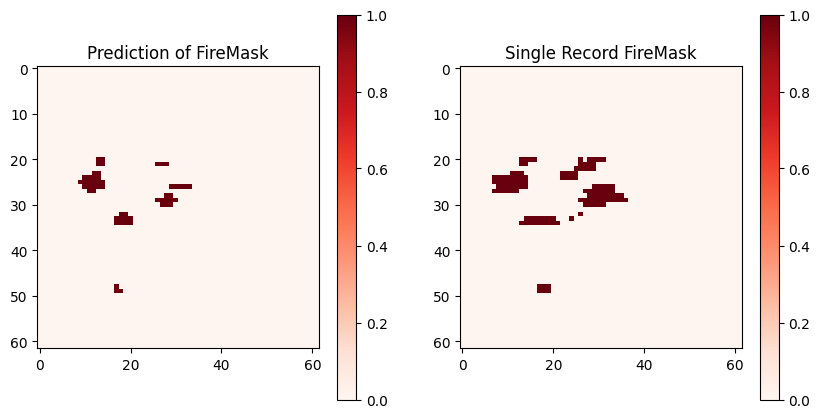

In [10]:
single_record_prediction = rf_model.predict(X_single)

plt.figure(figsize=(10, 5))

plt.subplot(1,2,1)
plt.title(f"Prediction of FireMask")
plt.imshow(single_record_prediction.reshape(62,62), cmap="Reds")
plt.colorbar()

plt.subplot(1,2,2)
plt.title(f"Single Record FireMask")
plt.imshow(y_single.reshape(62,62), cmap="Reds")
plt.colorbar()


plt.show()

In [ ]:
#no spatial context
loaded_california_data = np.load('/Users/altheawu/Downloads/UMBC/next_day_wildfire_spread/data_export/nonspatial_wildfire_data.npy.npz')

In [16]:
X_california = loaded_california_data['features']
y_california = loaded_california_data['labels']

X_california = X_california.transpose(1, 0, 2).reshape(11609, -1)

print(f"X_california shape: {X_california.shape}")
print(f"y_california shape: {y_california.shape}")

X_california shape: (11609, 49152)
y_california shape: (11609, 4096)


In [19]:
short_california = X_california[:500]

california_prediction = rf_model.predict(short_california)
print('success')

ValueError: X has 49152 features, but RandomForestClassifier is expecting 108 features as input.

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X_california, y_california, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (9287, 49152)
X_test shape: (2322, 49152)
y_train shape: (9287, 4096)
y_test shape: (2322, 4096)


In [18]:
rf_california_model = RandomForestClassifier(n_jobs =-1, max_depth=15)

rf_california_model.fit(X_train, y_train)

# Make predictions on the test set
california_predictions = rf_california_model.predict(X_test)

print('success')

KeyboardInterrupt: 